## Loading Main Packages

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

import wave_aux as wa

un_var= {"Hs": " [m]","Tp": " [s]","Dirp": " [°]","Dirm": " [°]"}

### Loading Data File

In [2]:
fin='./Point_out_000260.dat'
pdW=wa.readWave(1,'../data/'+fin,0)
pdW

,Hs,T02,T01,Tm10,Tp,Dirm,Dirp,Spr,Hs0,Tp0,...,Dirp2,gam2,spr2,Hs3,Tp3,Dirp3,gam3,spr3,uw,vw
YYYY-MM-DD hh:mm:ss,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00,0.000,1.52,1.52,1.52,1.96,270.0,227.3,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.51,5.12
1979-01-01 01:00:00,0.232,1.47,1.58,1.74,1.96,228.2,227.3,26.1,0.232,1.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.30,6.07
1979-01-01 02:00:00,0.706,2.23,2.41,2.65,3.02,229.1,226.5,31.7,0.706,3.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.40,8.38
1979-01-01 03:00:00,1.151,3.03,3.30,3.63,4.18,222.7,217.8,30.1,1.151,4.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.65,8.66
1979-01-01 04:00:00,1.472,3.66,4.00,4.42,5.08,219.4,216.1,27.6,1.472,5.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.12,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-30 20:00:00,1.140,4.57,5.20,6.09,7.52,205.5,221.8,37.8,NaN,NaN,...,152.6,2.24,0.5,0.257,4.43,280.2,2.20,0.4,-2.42,-2.08
2025-01-30 21:00:00,1.145,4.54,5.17,6.08,7.52,207.2,221.6,38.0,NaN,NaN,...,153.4,2.19,0.5,0.305,4.40,280.6,2.12,0.4,-2.58,-2.36
2025-01-30 22:00:00,1.154,4.46,5.10,6.02,7.51,209.0,221.2,39.2,NaN,NaN,...,159.3,2.27,0.4,0.356,4.37,281.0,2.06,0.5,-1.61,-0.75


## **Annual Maxima**

In [3]:
# Calling function for Annual Maxima
df=wa.am(pdW,'Hs')

# Sorting in descending order depending on Hs values
dfs = df.sort_values(by='Hs', ascending=True)

# Developing Plottin Position
n=len(dfs)
dfs['rank'] = dfs['Hs'].rank(method='first')
dfs['r_W']=dfs['rank']/(n+1)           # Weibull (1939)
dfs['r_G']=(dfs['rank']-0.44)/(n+0.12) # Gringorten (1963)
dfs['r_H']=(dfs['rank']-0.5)/n         # Hazen (1914)
dfs['r_B']=(dfs['rank']-0.31)/(n+0.38) # Beard (1943)
#dfs

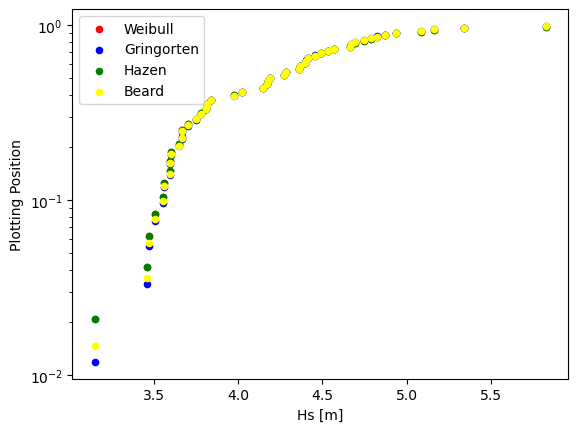

In [4]:
# Plotting Positions
fig, ax = plt.subplots()
dfs.plot.scatter(x='Hs', y='r_W', color='red', label='Weibull', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_G', color='blue', label='Gringorten', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_W', color='green', label='Hazen', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_B', color='yellow', label='Beard', ax=ax, logy=True)
plt.xlabel('Hs [m]')
plt.ylabel('Plotting Position')
plt.legend()

In [5]:
# Fitting GEV to data
var='Hs'
pp='r_W'
c, loc, scale = stats.genextreme.fit(dfs[var])
print(f"GEV parameters: c={c:.3f}, loc={loc:.3f}, scale={scale:.3f}")

GEV parameters: c=0.109, loc=3.969, scale=0.504


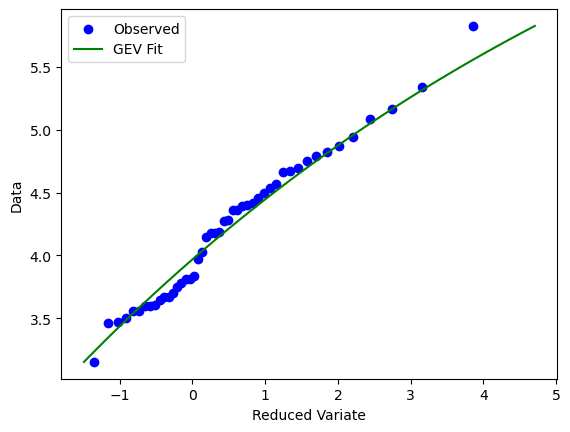

In [6]:
# CDF for plotting
#x_fit = np.linspace(2,10, 100)
x_fit = np.linspace(dfs[var].min(),dfs[var].max(), 100)
y_fit = stats.genextreme.cdf(x_fit, c, loc=loc, scale=scale)
y_fit_reduced = -np.log(-np.log(y_fit))
y = -np.log(-np.log(dfs[pp]))

plt.scatter(y, dfs['Hs'], color='blue', label='Observed')
plt.plot(y_fit_reduced, x_fit, color='green', label='GEV Fit')
plt.xlabel('Reduced Variate')
plt.ylabel('Data')
plt.legend()
plt.show()

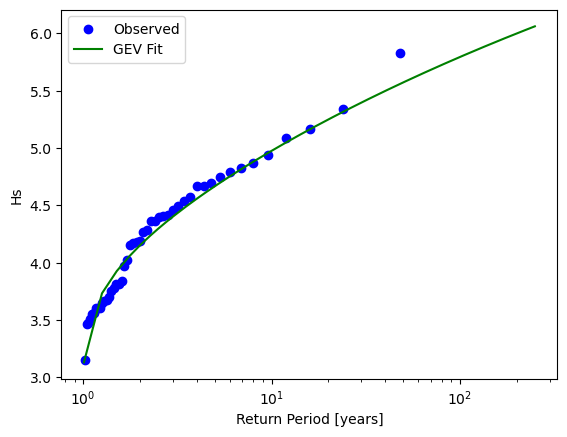

In [7]:
# Return periods for plotting (log scale often used)
T_fit=np.linspace(1.01, 250, 1000)
T=1/(1-dfs[pp])

# Convert T to non-exceedance probability
P_fit = 1 - 1/T_fit
data_fit = stats.genextreme.ppf(P_fit, c, loc=loc, scale=scale)

plt.scatter(T, dfs[var], color='blue', label='Observed')
plt.plot(T_fit, data_fit, color='green', label='GEV Fit')
plt.xscale('log')  # commonly log scale for return period
plt.xlabel('Return Period [years]')
plt.ylabel(var)
plt.legend()
plt.show()

In [8]:
rL, ci_L, ci_U, param=wa.gev_return_ci(dfs[var], T_fit, method="bootstrap", alpha=0.05, n_boot=1000)

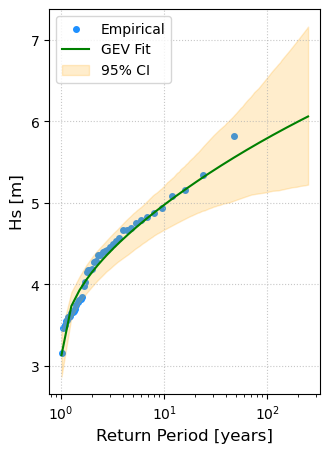

In [9]:
plt.figure(figsize=(3.5, 5))
plt.scatter(T, dfs[var], color='dodgerblue', label='Empirical', s=16)
plt.plot(T_fit, rL, color='green', label='GEV Fit')
plt.fill_between(T_fit, ci_L, ci_U,
                 color='orange', alpha=0.2,
                 label='95% CI')
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var+un_var[var], fontsize=12)
plt.legend()
plt.grid(True, alpha=0.7, linestyle='dotted')
plt.show()

In [10]:
# Example: Calculate return period for a given Hs value
c=param[0]
loc=param[1]
scale=param[2]
hs_value = 6.0  # Change this to your desired value
T_calculated = wa.value_to_return_period(hs_value, c, loc, scale)
print(f"For {var} = {hs_value:.2f} m, the return period is {T_calculated:.2f} years")

For Hs = 6.00 m, the return period is 201.66 years


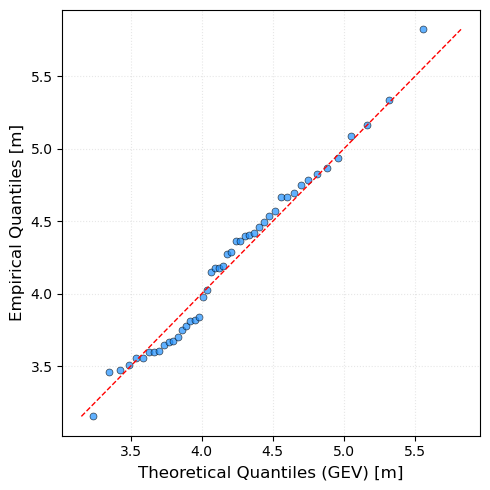

In [11]:
# Q-Q Plot: Theoretical vs Empirical Quantiles
# Sort observed data
observed_sorted = np.sort(dfs[var])
n = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
# Using Weibull plotting position: (i)/(n+1)
empirical_prob = np.arange(1, n+1) / (n + 1)

# Calculate theoretical quantiles from fitted GEV distribution
theoretical_quantiles = stats.genextreme.ppf(empirical_prob, c, loc=loc, scale=scale)

# Create Q-Q plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_quantiles, observed_sorted, color='dodgerblue', s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(theoretical_quantiles.min(), observed_sorted.min())
max_val = max(theoretical_quantiles.max(), observed_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel('Theoretical Quantiles (GEV)'+un_var[var], fontsize=12)
plt.ylabel('Empirical Quantiles'+un_var[var], fontsize=12)
#plt.title('Q-Q Plot: GEV Fit', fontsize=13, fontweight='bold')
#plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

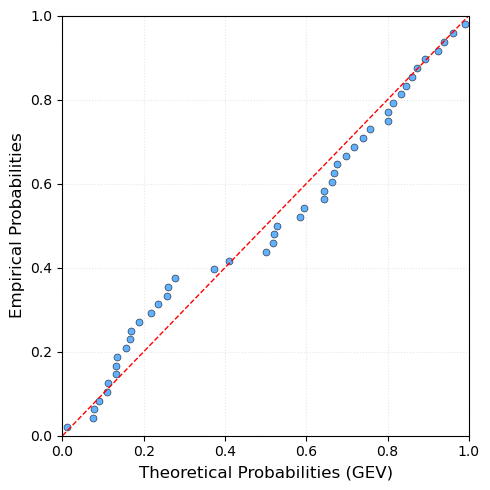

In [12]:
# P-P Plot: Theoretical vs Empirical Probabilities
# Sort observed data
observed_sorted = np.sort(dfs[var])
n = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
# Using Weibull plotting position: (i)/(n+1)
empirical_prob = np.arange(1, n+1) / (n + 1)

# Calculate theoretical probabilities from fitted GEV distribution
theoretical_prob = stats.genextreme.cdf(observed_sorted, c, loc=loc, scale=scale)

# Create P-P plot
figsize = (5, 5)  # Adjust figure size as needed
plt.figure(figsize=figsize)
plt.scatter(theoretical_prob, empirical_prob, color='dodgerblue', s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.xlabel('Theoretical Probabilities (GEV)', fontsize=12)
plt.ylabel('Empirical Probabilities', fontsize=12)
#plt.title('P-P Plot: GEV Fit', fontsize=13, fontweight='bold')
#plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

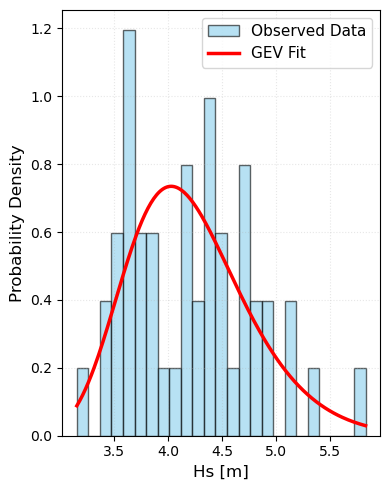

In [13]:
# PDF Plot: Histogram vs Fitted GEV Distribution
# Create x-values for the fitted PDF curve
x_pdf = np.linspace(dfs[var].min(), dfs[var].max(), 200)
# Calculate fitted PDF
pdf_fit = stats.genextreme.pdf(x_pdf, c, loc=loc, scale=scale)

# Create plot
figsize = (4, 5)  # Adjust figure size as needed
plt.figure(figsize=figsize)

# Plot histogram of observed data (normalized to represent density)
plt.hist(dfs[var], bins=25, density=True, alpha=0.6, color='skyblue', 
         edgecolor='black', label='Observed Data')

# Plot fitted GEV PDF
plt.plot(x_pdf, pdf_fit, 'r-', linewidth=2.5, label='GEV Fit')

plt.xlabel(var + un_var[var], fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
#plt.title('Probability Density Function: GEV Fit', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

# Peak Over Threshold

In [67]:
# Find peaks with minimum height and minimum distance
hrs_leg=24
thrsld=pdW[var].quantile(0.99)
peaks, properties = find_peaks(
    pdW[var].dropna(),
    height=thrsld,                        # Threshold
    distance=hrs_leg,                     # Time lag between peaks
    prominence=0.3                        # Peak must be prominent
)

# Extract peaks with full row data
peak_indices = pdW[var].dropna().index[peaks]
peaks_df = pdW.loc[peak_indices]

#print(peaks_df[['Hs', 'Tp', 'Dirp']])

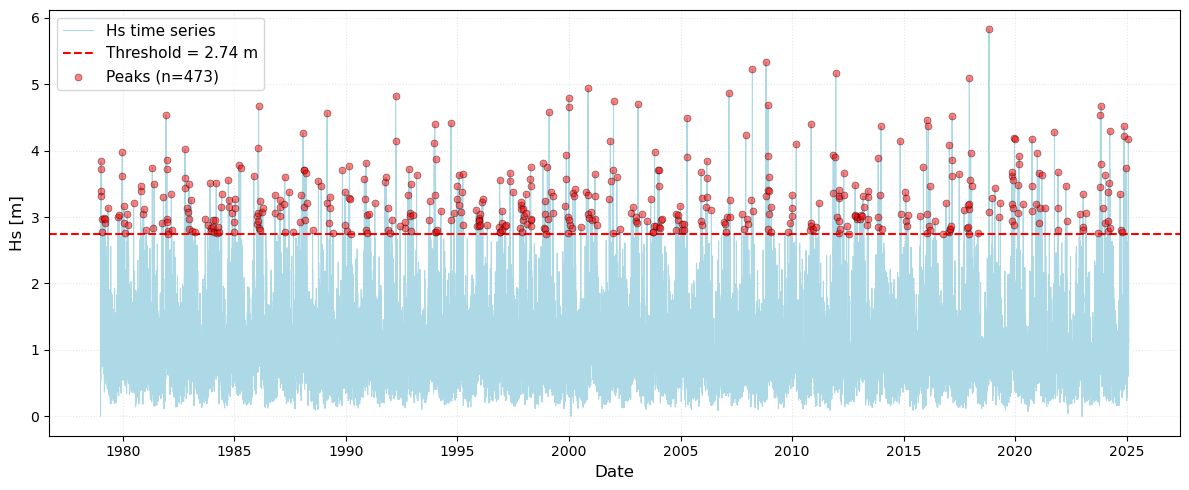

Total peaks identified: 473
Threshold value: 2.74 m
Mean peak value: 3.28 m
Max peak value: 5.83 m


In [68]:
# Plot original Hs time series with threshold and peaks
plt.figure(figsize=(12, 5))

# Plot the original Hs time series
plt.plot(pdW.index, pdW[var], color='lightblue', linewidth=0.8, label='Hs time series')

# Plot the threshold line
plt.axhline(y=thrsld, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {thrsld:.2f} m')

# Plot the identified peaks
plt.scatter(peaks_df.index, peaks_df[var], color='red', s=25, zorder=5, 
            edgecolors='black', alpha=0.5,linewidth=0.5, label=f'Peaks (n={len(peaks_df)})')

plt.xlabel('Date', fontsize=12)
plt.ylabel(var + un_var[var], fontsize=12)
#plt.title('Peak Over Threshold Analysis', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

print(f"Total peaks identified: {len(peaks_df)}")
print(f"Threshold value: {thrsld:.2f} m")
print(f"Mean peak value: {peaks_df[var].mean():.2f} m")
print(f"Max peak value: {peaks_df[var].max():.2f} m")

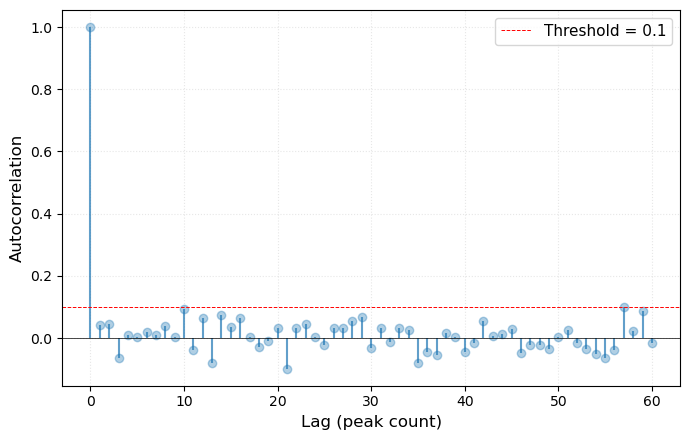

Decorrelation lag for peaks (at ACF < 0.1): 1 peaks
ACF at lag 0: 1.000
ACF at lag 1: 0.042
ACF at lag 2: 0.046
ACF at lag 5: 0.002
ACF at lag 10: 0.094
Total peaks analyzed: 473


In [69]:
# Evaluating autocorrelation and decorrelation time for peaks_df
var = 'Hs'

# Get peaks values
peaks_hs = peaks_df[var].values

# Calculating ACF for peaks
acf_peaks = wa.calculate_acf(peaks_hs, nlags=min(60, len(peaks_hs)-1))

# Plot autocorrelation
plt.figure(figsize=(7, 4.5))
markerline, stemlines, baseline = plt.stem(range(len(acf_peaks)), acf_peaks, basefmt=' ')
stemlines.set_alpha(0.7)
markerline.set_alpha(0.35)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=0.7, label='Threshold = 0.1')
plt.xlabel('Lag (peak count)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
#plt.title('Autocorrelation Function of Peaks', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

# Find decorrelation lag for peaks
threshold = 0.1
decorr_lag_peaks = None
for i, acf_val in enumerate(acf_peaks):
    if acf_val < threshold:
        decorr_lag_peaks = i
        break

print(f"Decorrelation lag for peaks (at ACF < {threshold}): {decorr_lag_peaks} peaks")
print(f"ACF at lag 0: {acf_peaks[0]:.3f}")
if len(acf_peaks) > 1:
    print(f"ACF at lag 1: {acf_peaks[1]:.3f}")
if len(acf_peaks) > 2:
    print(f"ACF at lag 2: {acf_peaks[2]:.3f}")
if len(acf_peaks) > 5:
    print(f"ACF at lag 5: {acf_peaks[5]:.3f}")
if len(acf_peaks) > 10:
    print(f"ACF at lag 10: {acf_peaks[10]:.3f}")
print(f"Total peaks analyzed: {len(peaks_hs)}")

In [71]:
# EVA Analysis with Generalized Pareto Distribution (POT method)
# L-moments fit following Hosking and Wallis (1997)
var = 'Hs'

# Extract peaks data
peaks_data = peaks_df[var].values
u = thrsld
exceedances = peaks_data - u
exceedances = exceedances[exceedances >= 0]

if len(exceedances) < 3:
    raise ValueError('Need at least 3 exceedances for L-moment GPD fitting.')

# Compute sample L-moments following Hosking & Wallis (1997)
# L_r = E[X * Pr(r-1, n-r)], where Pr are shifted Legendre polynomials
x = np.sort(exceedances)
n = len(x)

# Compute beta coefficients (unbiased estimators of PWM - Probability Weighted Moments)
# b_r = (1/n) * sum_{j=1}^n x_j * C(n-j, r) / C(n, r+1)
def compute_pwm(data, r):
    """Compute Probability Weighted Moments for GPD"""
    n = len(data)
    x = np.sort(data)
    pwm = 0.0
    for j in range(n):
        # Weight: (j / n) * ((j-1) / (n-1)) * ... * ((j-r+1) / (n-r+1))
        weight = 1.0
        for k in range(r):
            if n - k - 1 > 0:
                weight *= (j - k) / (n - k - 1)
        pwm += x[j] * weight / n
    return pwm

# Compute PWMs
b0 = compute_pwm(x, 0)  # alpha
b1 = compute_pwm(x, 1)  # beta
b2 = compute_pwm(x, 2)  # gamma

# Convert PWMs to L-moments
# L1 = b0
# L2 = 2*b1 - b0
# L3 = 6*b2 - 6*b1 + b0
l1 = b0
l2 = 2.0 * b1 - b0
l3 = 6.0 * b2 - 6.0 * b1 + b0

if l1 <= 0 or l2 <= 0:
    raise ValueError(f'Invalid sample L-moments: l1={l1:.4f}, l2={l2:.4f}. Both must be > 0.')

# L-moment ratios
t2 = l2 / l1  # L-CV
t3 = l3 / l2  # L-skewness

# GPD parameter estimation from L-moments (Hosking & Wallis 1997)
# For GPD: tau = l2/l1 = 1/(2 - xi)  =>  xi = 2 - 1/tau
# sigma = l1 * (1 - xi)
# mu is the threshold (u)

c_gp = 2.0 - 1.0 / t2  # shape parameter (xi)
scale_gp = l1 * (1.0 - c_gp)  # scale parameter (sigma)
loc_gp = u  # location (threshold)

if scale_gp <= 0:
    raise ValueError(f'Computed non-positive GPD scale: {scale_gp:.6f}')

if c_gp <= -0.5:
    print(f"Warning: shape parameter {c_gp:.4f} is outside typical range for GPD")

print("=" * 70)
print("GENERALIZED PARETO DISTRIBUTION (POT METHOD)")
print("L-moments Fit: Hosking & Wallis (1997)")
print("=" * 70)
print(f"Probability Weighted Moments (PWM):")
print(f"  b0 (alpha): {b0:.6f}")
print(f"  b1 (beta):  {b1:.6f}")
print(f"  b2 (gamma): {b2:.6f}")
print(f"\nL-moments:")
print(f"  L1: {l1:.6f}")
print(f"  L2: {l2:.6f}")
print(f"  L3: {l3:.6f}")
print(f"\nL-moment Ratios:")
print(f"  t2 (L-CV):        {t2:.6f}")
print(f"  t3 (L-skewness):  {t3:.6f}")
print(f"\nGeneralized Pareto Parameters:")
print(f"  Shape (ξ):     {c_gp:.6f}")
print(f"  Scale (σ):     {scale_gp:.6f}")
print(f"  Location (μ):  {loc_gp:.6f} (Threshold: {thrsld:.6f})")
print(f"\nData Summary:")
print(f"  Number of peaks:       {len(peaks_data)}")
print(f"  Number of exceedances: {len(exceedances)}")
print(f"  Mean exceedance:       {np.mean(exceedances):.6f}")
print(f"  Std exceedance:        {np.std(exceedances):.6f}")
print("=" * 70)

GENERALIZED PARETO DISTRIBUTION (POT METHOD)
L-moments Fit: Hosking & Wallis (1997)
Probability Weighted Moments (PWM):
  b0 (alpha): 0.540121
  b1 (beta):  0.403332
  b2 (gamma): 0.327335

L-moments:
  L1: 0.540121
  L2: 0.266544
  L3: 0.084139

L-moment Ratios:
  t2 (L-CV):        0.493490
  t3 (L-skewness):  0.315665

Generalized Pareto Parameters:
  Shape (ξ):     -0.026384
  Scale (σ):     0.554371
  Location (μ):  2.744000 (Threshold: 2.744000)

Data Summary:
  Number of peaks:       473
  Number of exceedances: 473
  Mean exceedance:       0.540121
  Std exceedance:        0.516117


In [73]:
# Fit GPD with SciPy (MLE) in a separate cell
# This overwrites c_gp, loc_gp, scale_gp for downstream plots/calc.
var = 'Hs'
peaks_data = peaks_df[var].values

u = thrsld
exceedances = peaks_data - u
exceedances = exceedances[exceedances >= 0]

if len(exceedances) < 3:
    raise ValueError('Need at least 3 exceedances for GPD fitting.')

# Fit on exceedances with location fixed at 0
c_gp, loc_exc, scale_gp = stats.genpareto.fit(exceedances, floc=0)
loc_gp = u

print("=" * 60)
print("GENERALIZED PARETO DISTRIBUTION (POT METHOD)")
print("=" * 60)
print("Fit method: SciPy genpareto.fit (MLE, exceedances above threshold)")
print(f"Generalized Pareto parameters:")
print(f"  Shape (c): {c_gp:.4f}")
print(f"  Location: {loc_gp:.4f} - Thrsld {thrsld:.4f}")
print(f"  Scale: {scale_gp:.4f}")
print(f"  Fitted exceedance location (fixed): {loc_exc:.4f}")
print(f"  Number of peaks: {len(peaks_data)}")
print("=" * 60)

GENERALIZED PARETO DISTRIBUTION (POT METHOD)
Fit method: SciPy genpareto.fit (MLE, exceedances above threshold)
Generalized Pareto parameters:
  Shape (c): -0.0555
  Location: 2.7440 - Thrsld 2.7440
  Scale: 0.5702
  Fitted exceedance location (fixed): 0.0000
  Number of peaks: 473


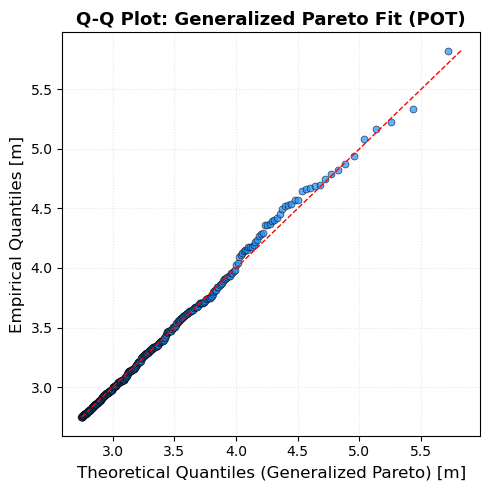

In [74]:
# Q-Q Plot: Theoretical vs Empirical Quantiles (Pareto)
# Sort observed peaks data
observed_sorted = np.sort(peaks_data)
n_peaks = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
empirical_prob_peaks = np.arange(1, n_peaks + 1) / (n_peaks + 1)

# Calculate theoretical quantiles from fitted Generalized Pareto distribution
theoretical_quantiles_gp = stats.genpareto.ppf(empirical_prob_peaks, c_gp, loc=loc_gp, scale=scale_gp)

# Create Q-Q plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_quantiles_gp, observed_sorted, color='dodgerblue', s=25, alpha=0.7, 
            edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(theoretical_quantiles_gp.min(), observed_sorted.min())
max_val = max(theoretical_quantiles_gp.max(), observed_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel(f'Theoretical Quantiles (Generalized Pareto){un_var[var]}', fontsize=12)
plt.ylabel(f'Empirical Quantiles{un_var[var]}', fontsize=12)
plt.title('Q-Q Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


In [ ]:
# P-P Plot: Theoretical vs Empirical Probabilities (Pareto)
# Calculate theoretical probabilities from fitted Generalized Pareto distribution
theoretical_prob_gp = stats.genpareto.cdf(observed_sorted, c_gp, loc=loc_gp, scale=scale_gp)

# Create P-P plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_prob_gp, empirical_prob_peaks, color='dodgerblue', s=25, alpha=0.7, 
            edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.xlabel('Theoretical Probabilities (Generalized Pareto)', fontsize=12)
plt.ylabel('Empirical Probabilities', fontsize=12)
plt.title('P-P Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


In [ ]:
# PDF Plot: Histogram vs Fitted Generalized Pareto Distribution
# Create x-values for the fitted PDF curve
x_pdf_gp = np.linspace(peaks_data.min(), peaks_data.max(), 200)

# Calculate fitted PDF
pdf_fit_gp = stats.genpareto.pdf(x_pdf_gp, c_gp, loc=loc_gp, scale=scale_gp)

# Create plot
plt.figure(figsize=(5, 4))

# Plot histogram of observed data (normalized to represent density)
plt.hist(peaks_data, bins=20, density=True, alpha=0.6, color='skyblue', 
         edgecolor='black', label='Observed Peaks')

# Plot fitted Generalized Pareto PDF
plt.plot(x_pdf_gp, pdf_fit_gp, 'r-', linewidth=2.5, label='Generalized Pareto Fit')

plt.xlabel(var + un_var[var], fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Probability Density Function: Generalized Pareto (POT)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


In [ ]:
# Return Period Analysis for Generalized Pareto (POT method)
# Number of peaks per year
n_peaks_total = len(peaks_df)
# Assuming the data covers a certain time period, calculate peaks per year
data_duration_years = (pdW.index[-1] - pdW.index[0]).days / 365.25
peaks_per_year = n_peaks_total / data_duration_years

print(f"Data duration: {data_duration_years:.2f} years")
print(f"Total peaks: {n_peaks_total}")
print(f"Average peaks per year: {peaks_per_year:.2f}")

# Define return periods to calculate
return_periods = np.array([2, 5, 10, 25, 50, 100, 250])

# For POT method: P(X > x) = lambda * P_gp(X > x)
# where lambda is peaks per year
# Return period T = 1 / (lambda * (1 - P_gp(x)))

# Calculate quantiles for each return period
quantiles_pot = []
for T in return_periods:
    # Solve for x: T = 1 / (lambda * (1 - CDF(x)))
    # 1 - CDF(x) = 1 / (T * lambda)
    exceedance_prob = 1 / (T * peaks_per_year)
    # CDF(x) = 1 - exceedance_prob
    cdf_target = 1 - exceedance_prob
    x_quantile = stats.genpareto.ppf(cdf_target, c_gp, loc=loc_gp, scale=scale_gp)
    quantiles_pot.append(x_quantile)

quantiles_pot = np.array(quantiles_pot)

# Create return period plot
plt.figure(figsize=(8, 5))
plt.scatter(return_periods, quantiles_pot, color='red', s=100, zorder=5, label='POT Fit (Generalized Pareto)', alpha=0.7)
plt.plot(return_periods, quantiles_pot, 'r-', linewidth=1.5, alpha=0.5)
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var + un_var[var], fontsize=12)
plt.title('Return Period Analysis: Generalized Pareto (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted', which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print return period values
print("\nReturn Period Quantiles (POT Method):")
print("Return Period (years) | Quantile Value")
print("-" * 40)
for T, q in zip(return_periods, quantiles_pot):
    print(f"{T:20.1f} | {q:14.3f} m")


In [40]:
np.arange(1, n_peaks + 1)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18